In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
pd.options.display.max_columns=None


In [2]:
df = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2024/games.csv')
df.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,09/08/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,09/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,09/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,09/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,09/11/2022,13:00:00,CIN,PIT,20,23


In [3]:
df1 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2024/players.csv')
df1.head()

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan


In [4]:
combined = pd.concat([df,df1])
combined.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore,nflId,height,weight,birthDate,collegeName,position,displayName
0,2.022091e+09,2022.0,1.0,09/08/2022,20:20:00,LA,BUF,10.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,ATL,NO,26.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CAR,CLE,24.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CHI,SF,19.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CIN,PIT,20.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1819 entries, 0 to 1682
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gameId             136 non-null    float64
 1   season             136 non-null    float64
 2   week               136 non-null    float64
 3   gameDate           136 non-null    object 
 4   gameTimeEastern    136 non-null    object 
 5   homeTeamAbbr       136 non-null    object 
 6   visitorTeamAbbr    136 non-null    object 
 7   homeFinalScore     136 non-null    float64
 8   visitorFinalScore  136 non-null    float64
 9   nflId              1683 non-null   float64
 10  height             1683 non-null   object 
 11  weight             1683 non-null   float64
 12  birthDate          1204 non-null   object 
 13  collegeName        1683 non-null   object 
 14  position           1683 non-null   object 
 15  displayName        1683 non-null   object 
dtypes: float64(7), object(9)
memo

In [6]:
combined.dtypes

gameId               float64
season               float64
week                 float64
gameDate              object
gameTimeEastern       object
homeTeamAbbr          object
visitorTeamAbbr       object
homeFinalScore       float64
visitorFinalScore    float64
nflId                float64
height                object
weight               float64
birthDate             object
collegeName           object
position              object
displayName           object
dtype: object

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
gameId,136.0,2.022099e+09,5996.613763,2.022091e+09,2.022093e+09,2.022101e+09,2.022102e+09,2.022111e+09
season,136.0,2.022000e+03,0.000000,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03
week,136.0,4.845588e+00,2.567254,1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,9.000000e+00
homeFinalScore,136.0,2.266912e+01,8.659874,3.000000e+00,1.700000e+01,2.250000e+01,2.700000e+01,4.900000e+01
visitorFinalScore,136.0,2.094853e+01,9.731446,0.000000e+00,1.475000e+01,2.000000e+01,2.700000e+01,4.800000e+01
nflId,1683.0,4.822170e+04,5217.040133,2.551100e+04,4.482850e+04,4.787200e+04,5.347150e+04,5.524100e+04
weight,1683.0,2.457243e+02,47.119299,1.530000e+02,2.050000e+02,2.360000e+02,2.900000e+02,3.800000e+02


In [8]:
combined.shape

(1819, 16)

<Axes: >

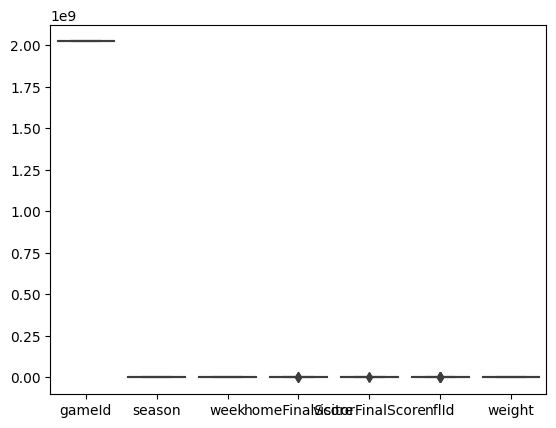

In [9]:
sns.boxplot(combined)

<Axes: >

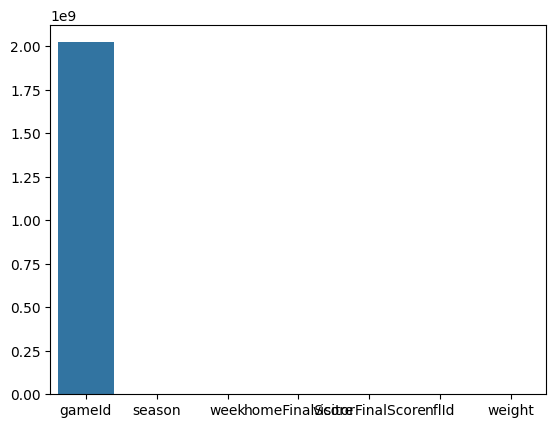

In [10]:
sns.barplot(combined)

<Axes: >

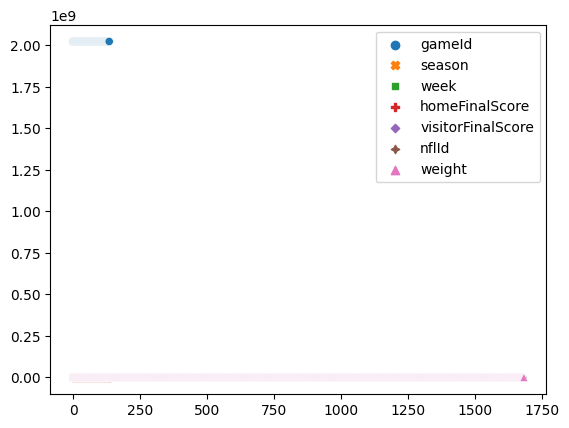

In [11]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


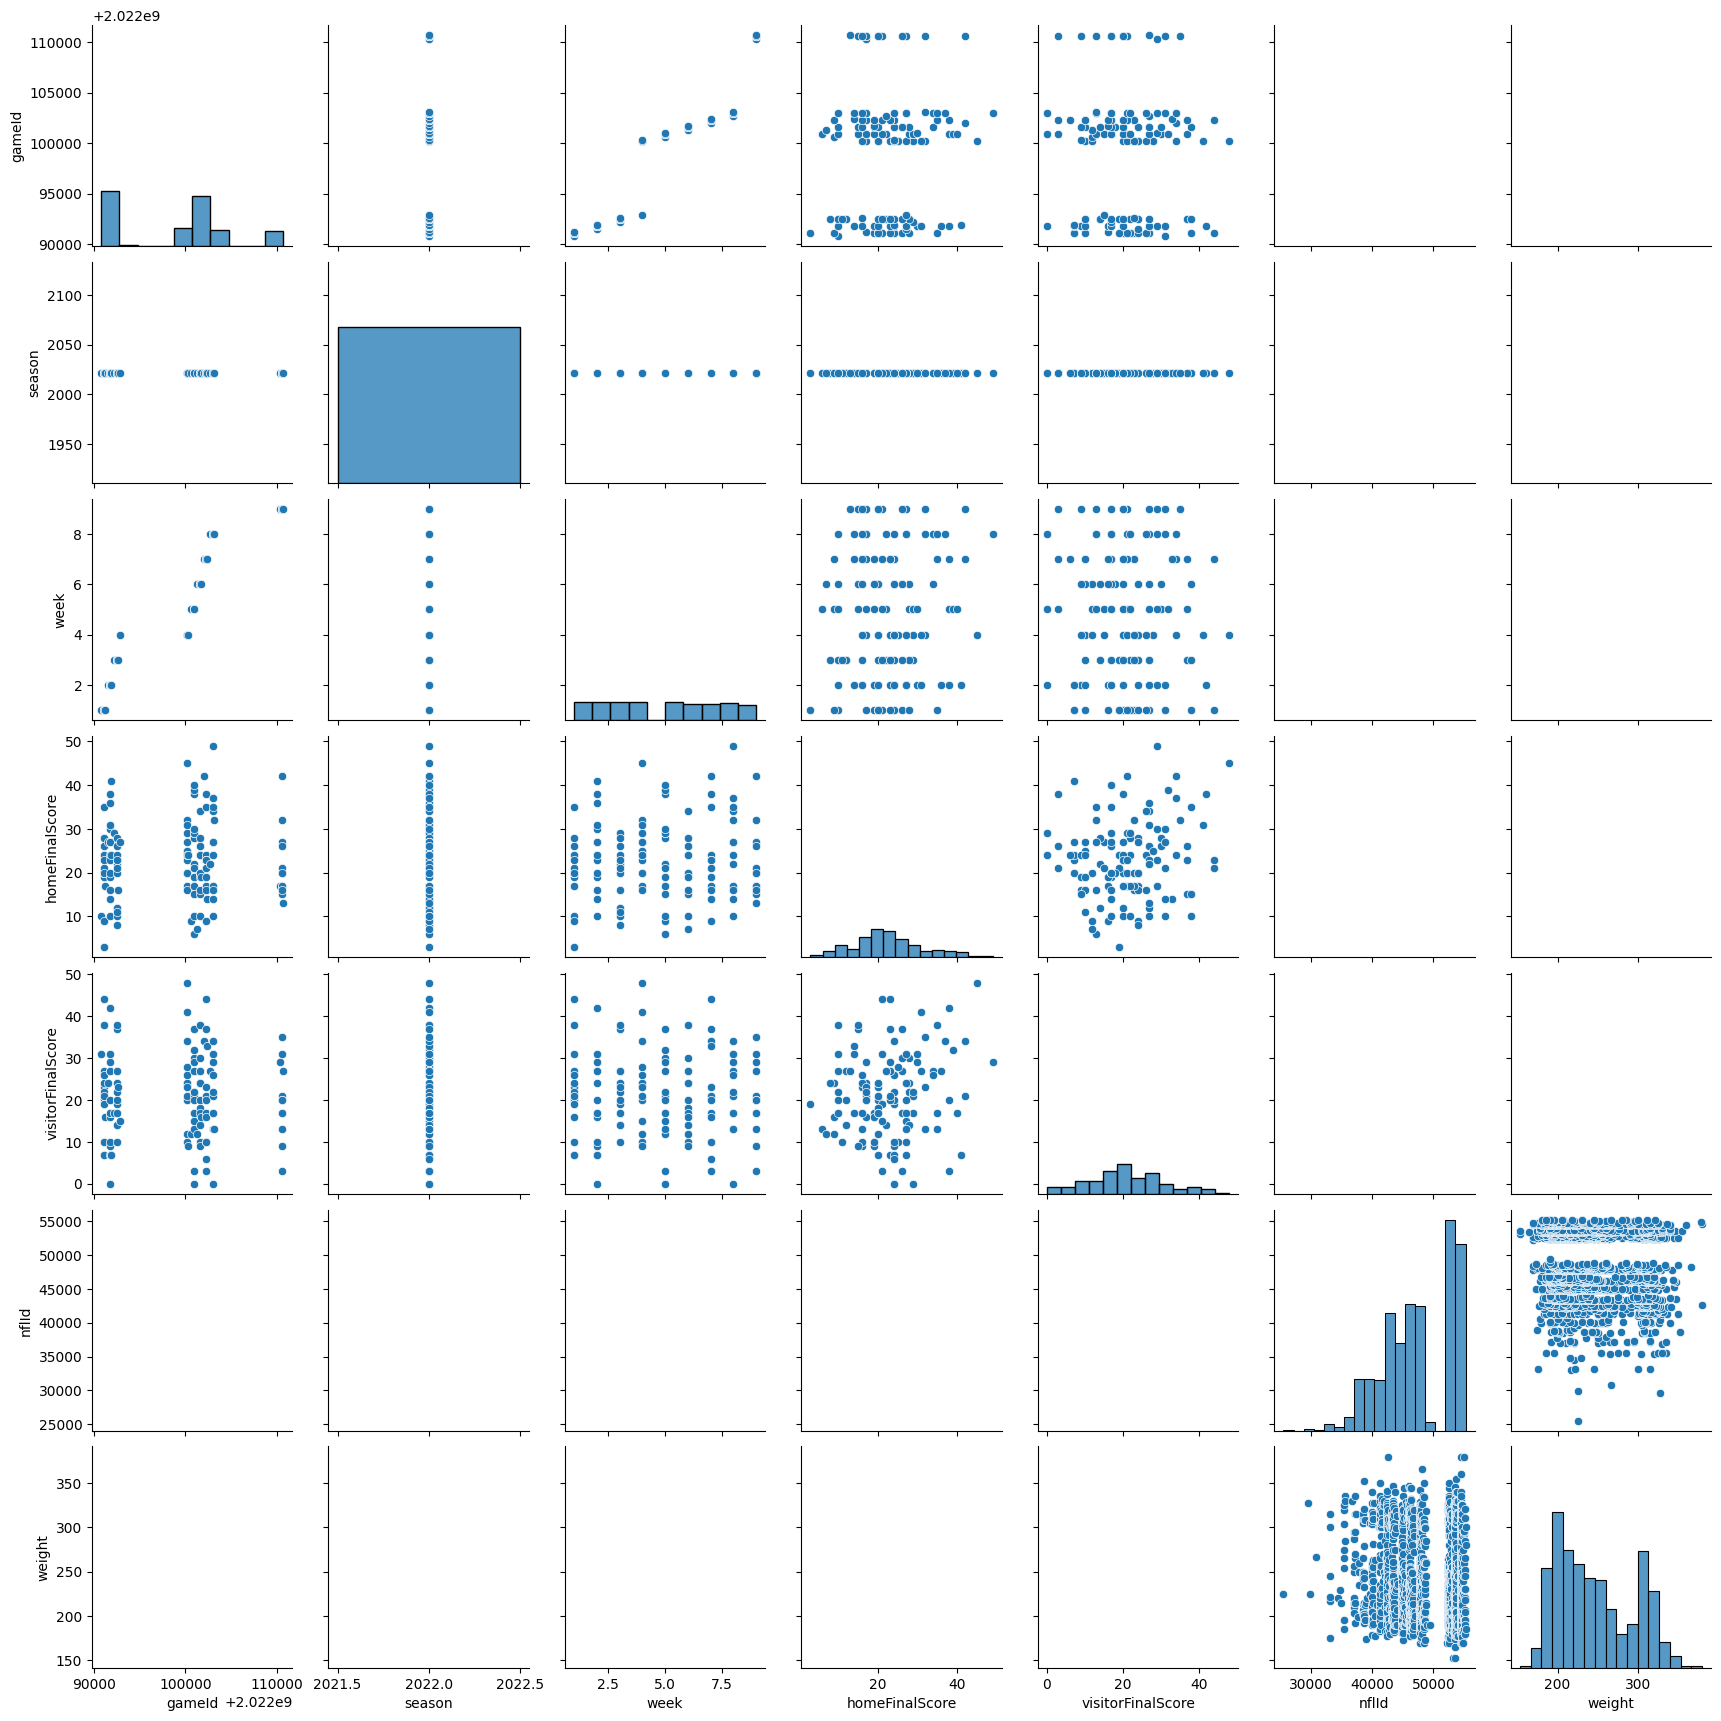

In [12]:
sns.pairplot(combined)

/tmp/ipykernel_31/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(combined)


<Axes: ylabel='Density'>

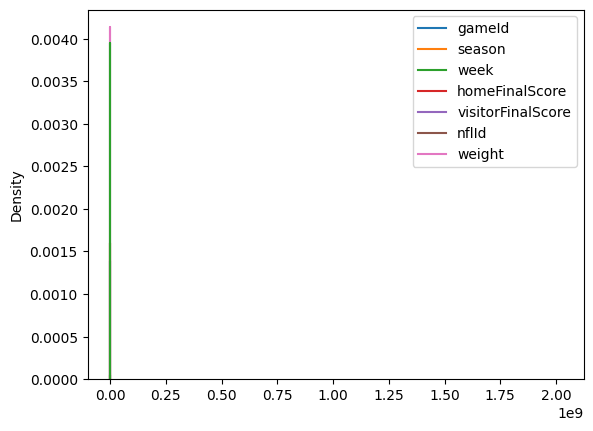

In [13]:
sns.kdeplot(combined)

<Axes: >

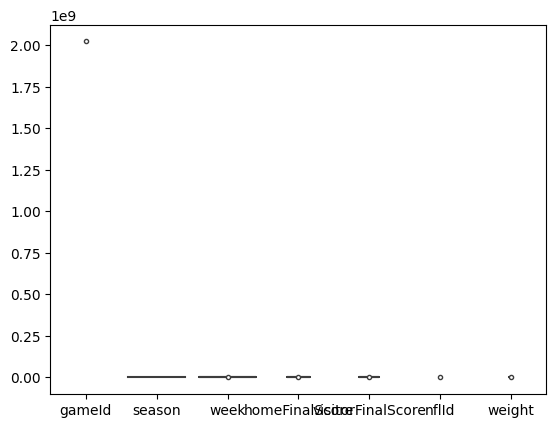

In [14]:
sns.violinplot(combined)

<Axes: >

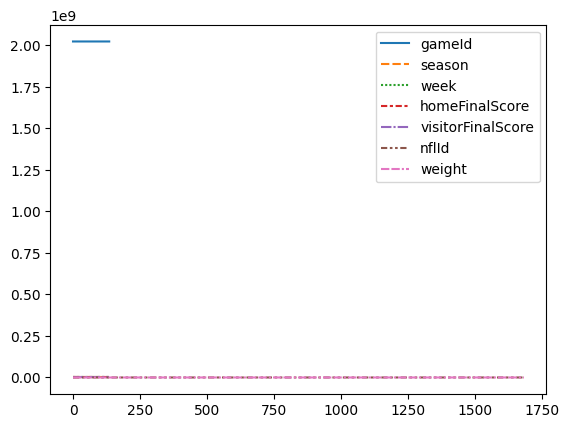

In [15]:
sns.lineplot(combined)

In [16]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of             gameId  season  week    gameDate gameTimeEastern homeTeamAbbr  \
0     2.022091e+09  2022.0   1.0  09/08/2022        20:20:00           LA   
1     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          ATL   
2     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CAR   
3     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CHI   
4     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CIN   
...            ...     ...   ...         ...             ...          ...   
1678           NaN     NaN   NaN         NaN             NaN          NaN   
1679           NaN     NaN   NaN         NaN             NaN          NaN   
1680           NaN     NaN   NaN         NaN             NaN          NaN   
1681           NaN     NaN   NaN         NaN             NaN          NaN   
1682           NaN     NaN   NaN         NaN             NaN          NaN   

     visitor

In [17]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of             gameId  season  week    gameDate gameTimeEastern homeTeamAbbr  \
0     2.022091e+09  2022.0   1.0  09/08/2022        20:20:00           LA   
1     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          ATL   
2     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CAR   
3     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CHI   
4     2.022091e+09  2022.0   1.0  09/11/2022        13:00:00          CIN   
...            ...     ...   ...         ...             ...          ...   
1678           NaN     NaN   NaN         NaN             NaN          NaN   
1679           NaN     NaN   NaN         NaN             NaN          NaN   
1680           NaN     NaN   NaN         NaN             NaN          NaN   
1681           NaN     NaN   NaN         NaN             NaN          NaN   
1682           NaN     NaN   NaN         NaN             NaN          NaN   

     visitor

In [18]:
cat_cols = combined.select_dtypes(include='object')

In [19]:
for i in cat_cols:
    print(i)
    combined[i].value_counts()
    print('_'*50)

gameDate
__________________________________________________
gameTimeEastern
__________________________________________________
homeTeamAbbr
__________________________________________________
visitorTeamAbbr
__________________________________________________
height
__________________________________________________
birthDate
__________________________________________________
collegeName
__________________________________________________
position
__________________________________________________
displayName
__________________________________________________


In [20]:
num_cols = combined.select_dtypes(include='number')

In [21]:
for i in num_cols:
    print(i)
    combined[i].value_counts()
    print('_______'*50)

gameId
______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
season
______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
week
_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

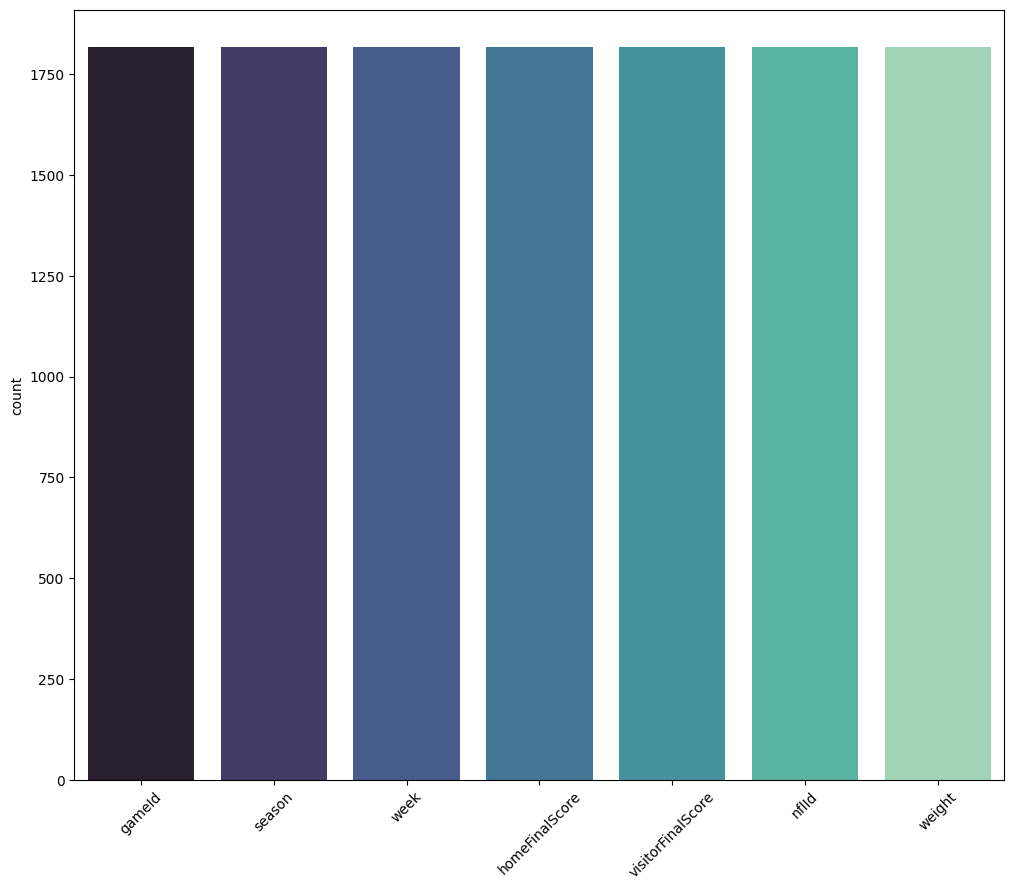

In [22]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

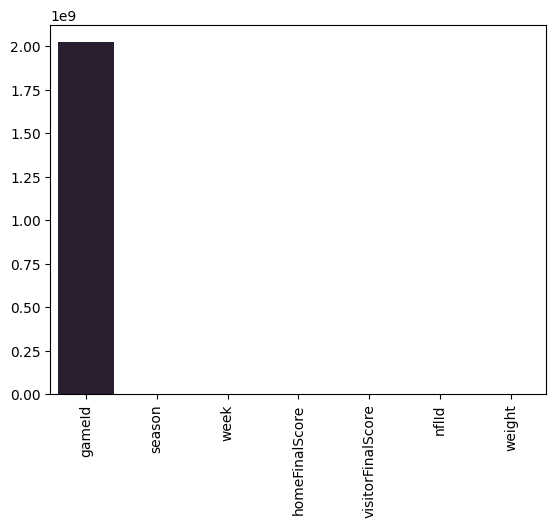

In [23]:
sns.barplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([-250.,    0.,  250.,  500.,  750., 1000., 1250., 1500., 1750.,
        2000.]),
 [Text(-250.0, 0, '−250'),
  Text(0.0, 0, '0'),
  Text(250.0, 0, '250'),
  Text(500.0, 0, '500'),
  Text(750.0, 0, '750'),
  Text(1000.0, 0, '1000'),
  Text(1250.0, 0, '1250'),
  Text(1500.0, 0, '1500'),
  Text(1750.0, 0, '1750'),
  Text(2000.0, 0, '2000')])

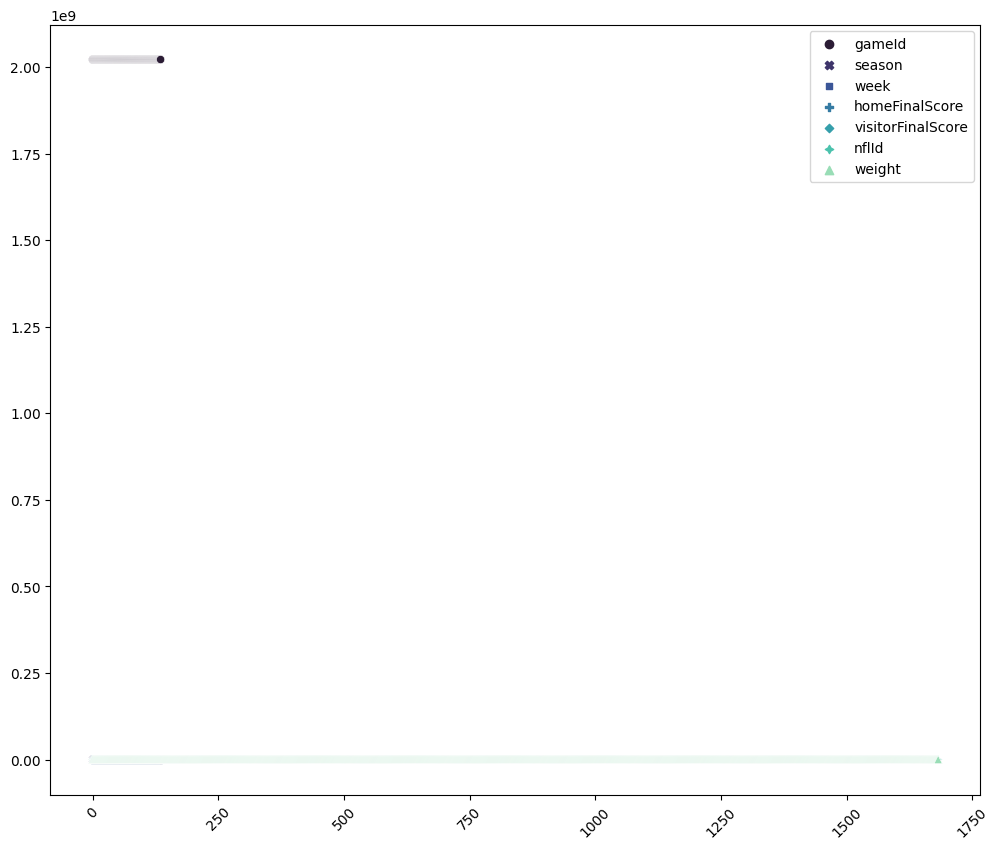

In [24]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=combined,palette='mako')
plt.xticks(rotation=45)

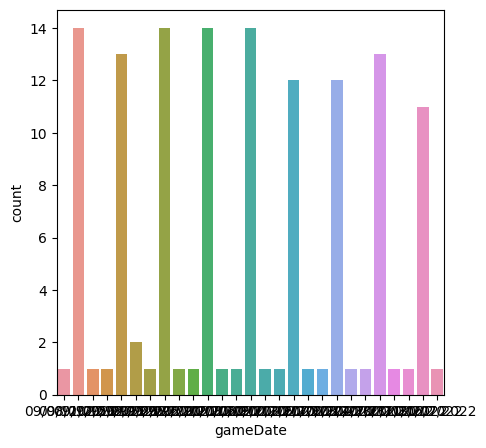

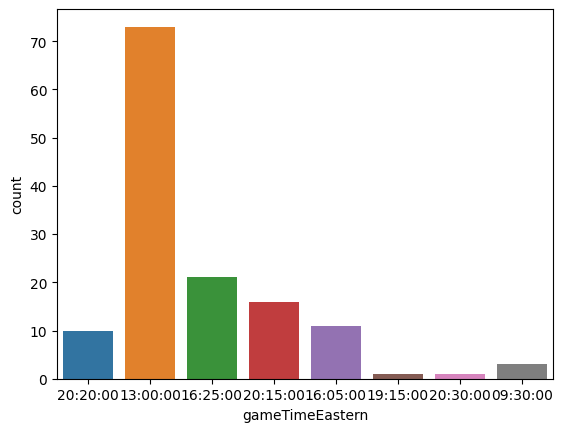

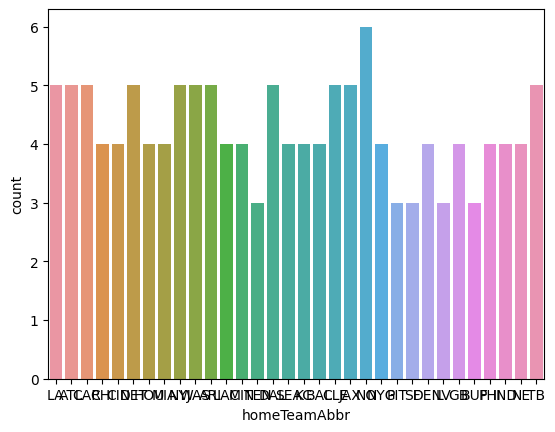

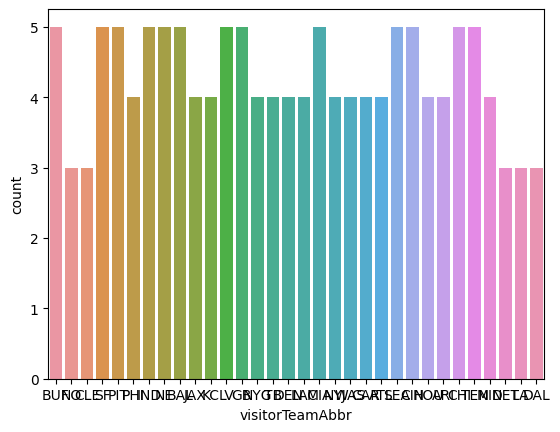

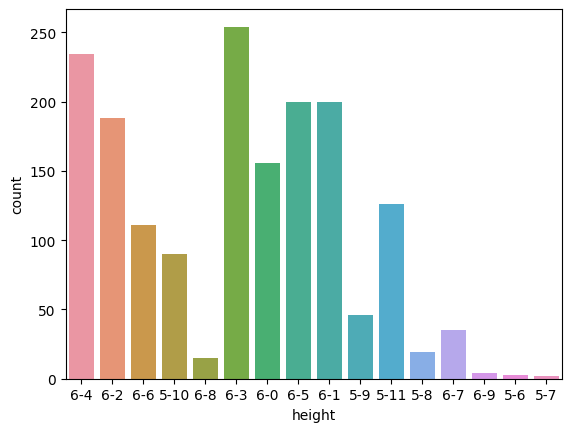

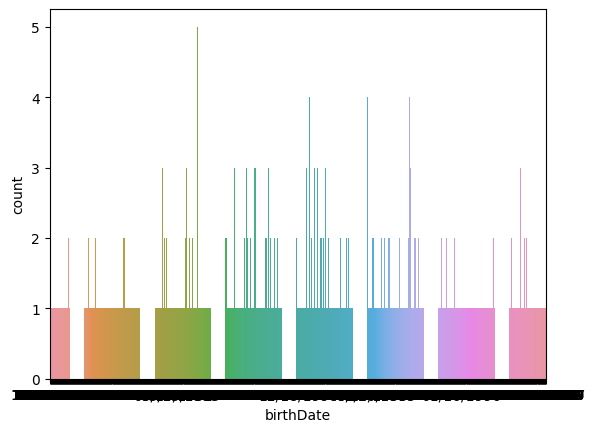

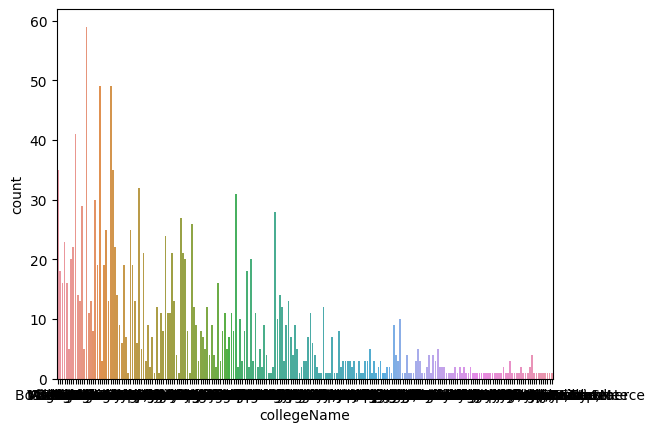

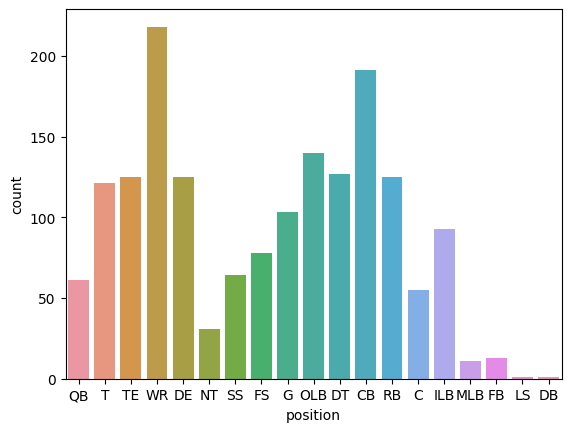

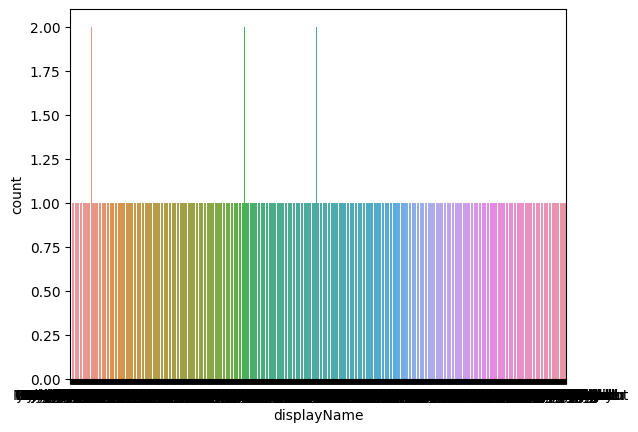

In [25]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    x=i
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

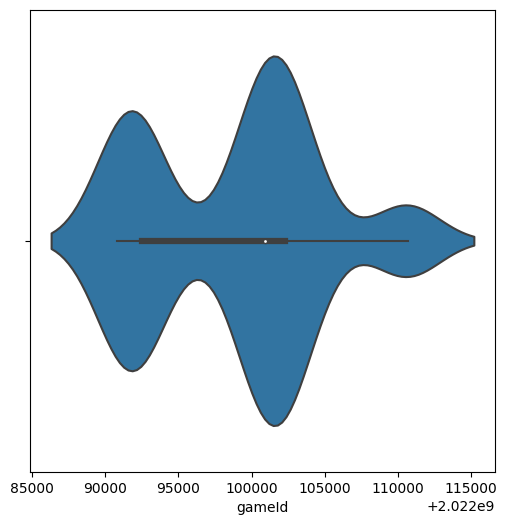

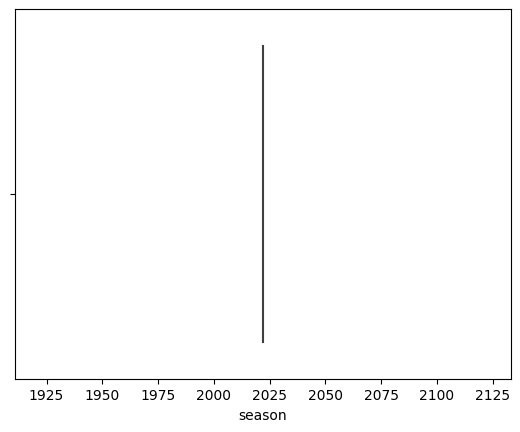

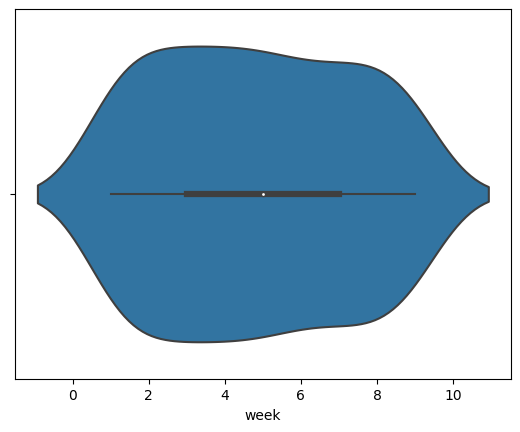

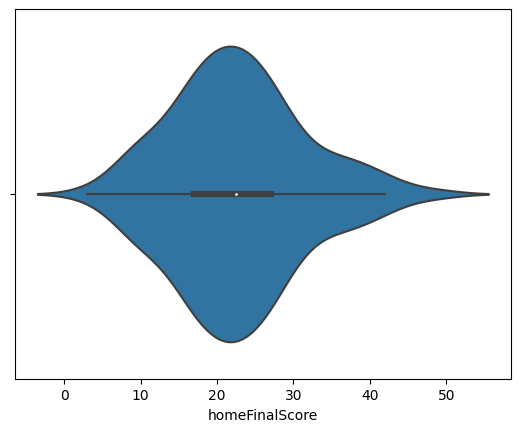

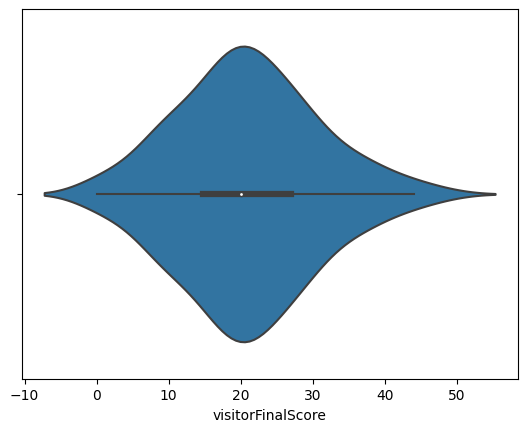

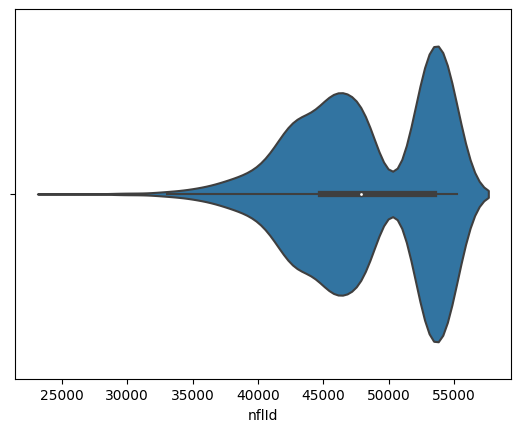

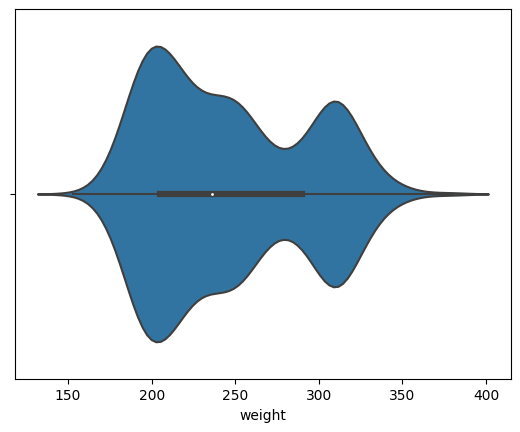

In [26]:
plt.figure(figsize=(6,6))
x=1
for i in num_cols:
    x=i
    sns.violinplot(data=combined,x=i)
    print('\n')
    plt.show()

In [27]:
combined.shape

(1819, 16)

In [29]:
combined.columns

Index(['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern',
       'homeTeamAbbr', 'visitorTeamAbbr', 'homeFinalScore',
       'visitorFinalScore', 'nflId', 'height', 'weight', 'birthDate',
       'collegeName', 'position', 'displayName'],
      dtype='object')

In [28]:
combined.season.unique

<bound method Series.unique of 0       2022.0
1       2022.0
2       2022.0
3       2022.0
4       2022.0
         ...  
1678       NaN
1679       NaN
1680       NaN
1681       NaN
1682       NaN
Name: season, Length: 1819, dtype: float64>

In [ ]:
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [30]:
combined.isnull().sum()/len(combined*100)

gameId               0.925234
season               0.925234
week                 0.925234
gameDate             0.925234
gameTimeEastern      0.925234
homeTeamAbbr         0.925234
visitorTeamAbbr      0.925234
homeFinalScore       0.925234
visitorFinalScore    0.925234
nflId                0.074766
height               0.074766
weight               0.074766
birthDate            0.338098
collegeName          0.074766
position             0.074766
displayName          0.074766
dtype: float64

In [31]:
combined['season'].value_counts().head(9).index[1:]

Index([], dtype='float64', name='season')

In [32]:
# Rebuild type of season columns
for i in combined ['season'].value_counts().head(9).index[1:]:
    combined[i]=combined['season'].str.contains(i)

In [33]:
combined.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore,nflId,height,weight,birthDate,collegeName,position,displayName
0,2.022091e+09,2022.0,1.0,09/08/2022,20:20:00,LA,BUF,10.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,ATL,NO,26.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CAR,CLE,24.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CHI,SF,19.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CIN,PIT,20.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
cat_cols

,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,height,birthDate,collegeName,position,displayName
0,09/08/2022,20:20:00,LA,BUF,NaN,NaN,NaN,NaN,NaN
1,09/11/2022,13:00:00,ATL,NO,NaN,NaN,NaN,NaN,NaN
2,09/11/2022,13:00:00,CAR,CLE,NaN,NaN,NaN,NaN,NaN
3,09/11/2022,13:00:00,CHI,SF,NaN,NaN,NaN,NaN,NaN
4,09/11/2022,13:00:00,CIN,PIT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1678,NaN,NaN,NaN,NaN,6-6,NaN,Indiana,DT,Ryder Anderson
1679,NaN,NaN,NaN,NaN,6-0,NaN,Iowa State,ILB,Jake Hummel
1680,NaN,NaN,NaN,NaN,6-2,NaN,Pennsylvania,DT,Prince Emili
1681,NaN,NaN,NaN,NaN,6-1,NaN,Buffalo,CB,Ja'Marcus Ingram


In [35]:
num_cols

,gameId,season,week,homeFinalScore,visitorFinalScore,nflId,weight
0,2.022091e+09,2022.0,1.0,10.0,31.0,NaN,NaN
1,2.022091e+09,2022.0,1.0,26.0,27.0,NaN,NaN
2,2.022091e+09,2022.0,1.0,24.0,26.0,NaN,NaN
3,2.022091e+09,2022.0,1.0,19.0,10.0,NaN,NaN
4,2.022091e+09,2022.0,1.0,20.0,23.0,NaN,NaN
...,...,...,...,...,...,...,...
1678,NaN,NaN,NaN,NaN,NaN,55200.0,266.0
1679,NaN,NaN,NaN,NaN,NaN,55212.0,230.0
1680,NaN,NaN,NaN,NaN,NaN,55239.0,300.0
1681,NaN,NaN,NaN,NaN,NaN,55240.0,185.0


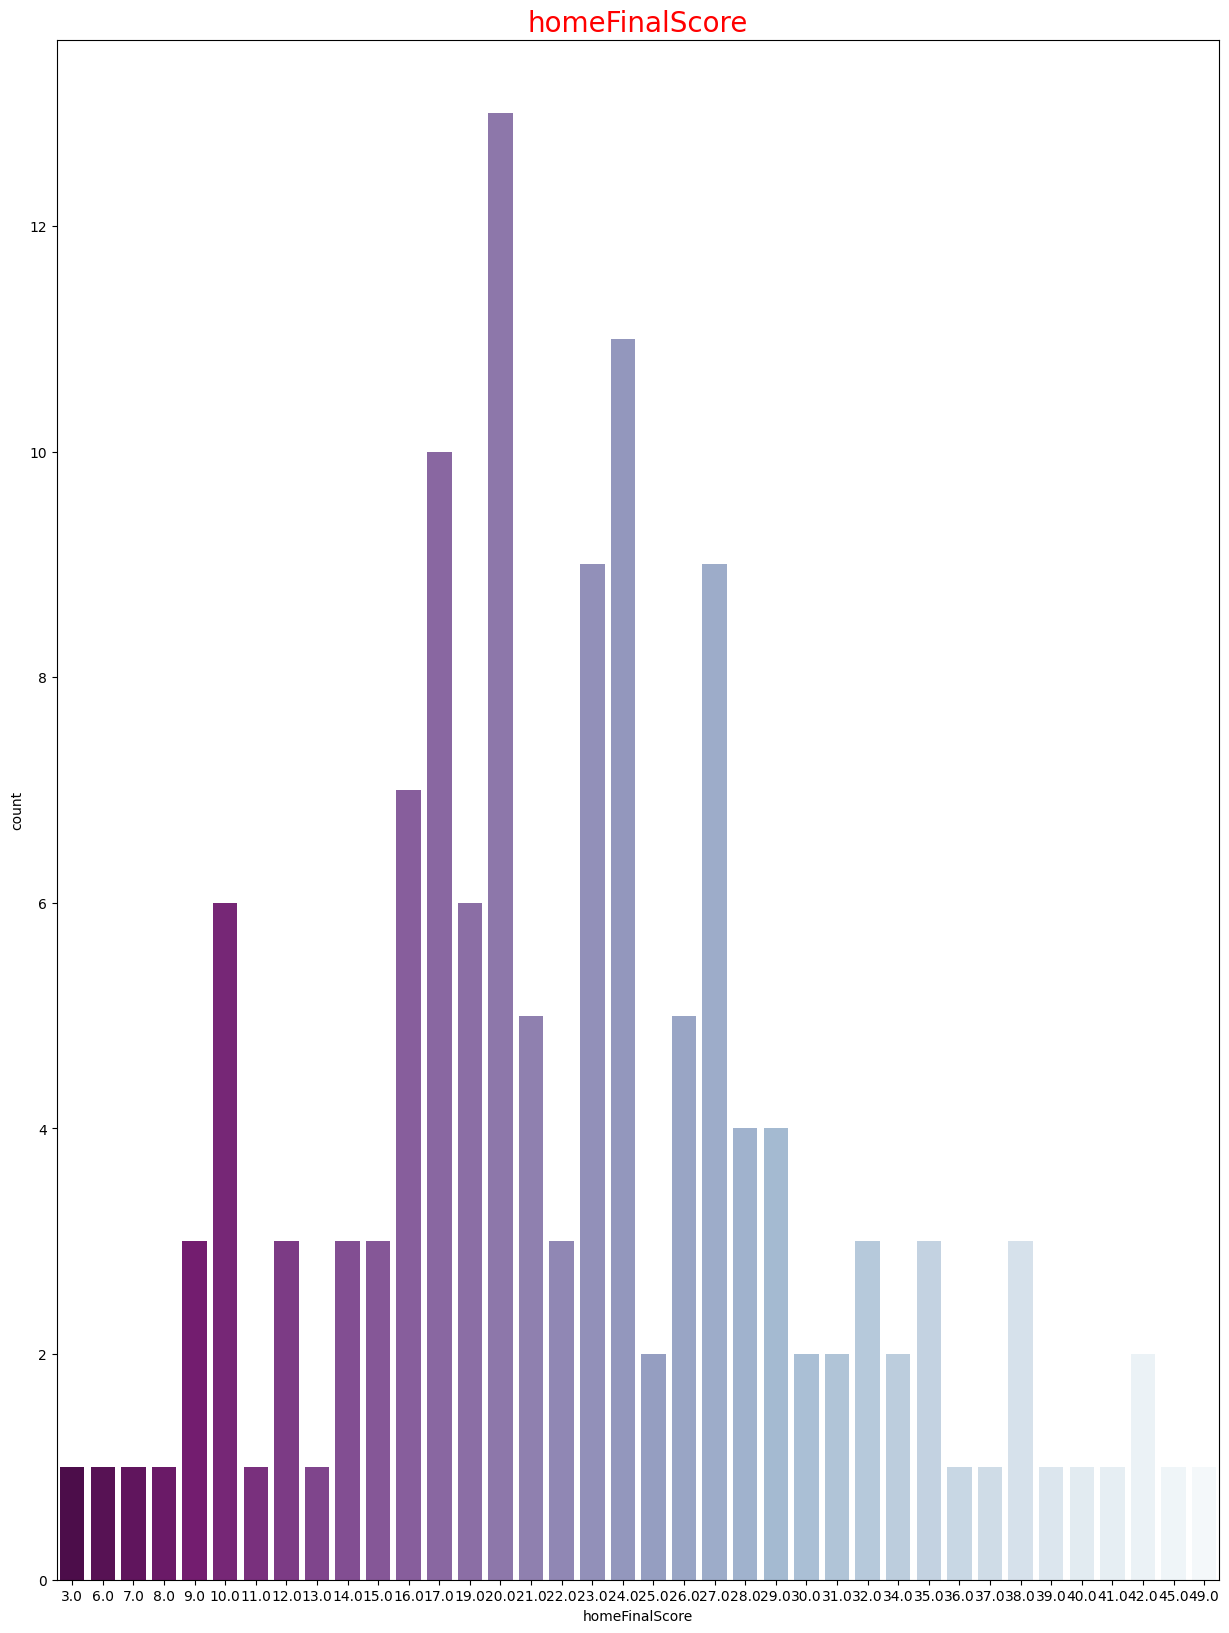

In [36]:
plt.figure(figsize=(15,20))
sns.countplot(data=combined,x ='homeFinalScore',palette='BuPu_r')
plt.title('homeFinalScore',size=20,color='red')
plt.show()

In [37]:
combined.head()

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore,nflId,height,weight,birthDate,collegeName,position,displayName
0,2.022091e+09,2022.0,1.0,09/08/2022,20:20:00,LA,BUF,10.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,ATL,NO,26.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CAR,CLE,24.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CHI,SF,19.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.022091e+09,2022.0,1.0,09/11/2022,13:00:00,CIN,PIT,20.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
combined['homeFinalScore'].value_counts(normalize=True)*100

homeFinalScore
20.0    9.558824
24.0    8.088235
17.0    7.352941
23.0    6.617647
27.0    6.617647
16.0    5.147059
10.0    4.411765
19.0    4.411765
21.0    3.676471
26.0    3.676471
28.0    2.941176
29.0    2.941176
14.0    2.205882
32.0    2.205882
12.0    2.205882
22.0    2.205882
15.0    2.205882
38.0    2.205882
9.0     2.205882
35.0    2.205882
31.0    1.470588
42.0    1.470588
34.0    1.470588
25.0    1.470588
30.0    1.470588
37.0    0.735294
40.0    0.735294
49.0    0.735294
7.0     0.735294
41.0    0.735294
39.0    0.735294
6.0     0.735294
45.0    0.735294
11.0    0.735294
8.0     0.735294
36.0    0.735294
3.0     0.735294
13.0    0.735294
Name: proportion, dtype: float64

In [39]:
combined.shape

(1819, 16)